# Final Project: N-BEATS

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning.accelerators.cuda").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning.callbacks.model_summary").setLevel(logging.ERROR)
logging.getLogger("lightning_fabric").setLevel(logging.ERROR)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 0 Load Data

In [3]:
df_raw = pd.read_parquet("../../data/processed/merged_features_weekly.parquet")

commodities = [
    "Beetroot",
    "Bulb Onions (Yellow)",
    "Cabbage",
    "Carrots",
    "Cucumbers",
    "Curly kale",
    "Lettuce",
    "Tomatoes (Round)",
]

df = df_raw[df_raw["commodity"].isin(commodities)].copy()
df = df.sort_values(["commodity", "date"]).reset_index(drop=True)

if "target_was_missing" not in df.columns:
    df["target_was_missing"] = 0

train_df = df[df["split"] == "train"].copy()
test_df  = df[df["split"] == "test"].copy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Commodities: {train_df['commodity'].nunique()}")

Train: 1876 rows | Test: 240 rows
Commodities: 4


In [4]:
nf_train = train_df[["commodity", "date", "target_price"]].copy()
nf_train.columns = ["unique_id", "ds", "y"]
nf_train["ds"] = pd.to_datetime(nf_train["ds"])
nf_train["y"] = nf_train["y"].astype(float)

# Keep was_missing flag so evaluation mirrors ARIMA / TimeGPT (non-imputed rows only)
nf_test = test_df[["commodity", "date", "target_price", "target_was_missing"]].copy()
nf_test.columns = ["unique_id", "ds", "y", "was_missing"]
nf_test["ds"] = pd.to_datetime(nf_test["ds"])
nf_test["y"] = nf_test["y"].astype(float)

max_h = nf_test.groupby("unique_id").size().max()
print(f"Max forecast horizon: {max_h} weeks")

Max forecast horizon: 60 weeks


## 1 Train N-BEATS

In [5]:
from neuralforecast.core import NeuralForecast
from neuralforecast.models import NBEATS

horizon = max_h

nbeats = NBEATS(
    h=horizon,
    input_size=2 * horizon,
    max_steps=1000,
    early_stop_patience_steps=5,
)

nf = NeuralForecast(models=[nbeats], freq="W")

start_time = time.time()
nf.fit(df=nf_train, val_size=horizon)
train_elapsed = time.time() - start_time
print(f"Training completed in {train_elapsed:.1f}s")

Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training completed in 14.3s


## 2 Forecast

In [6]:
start_time = time.time()
nbeats_forecasts = nf.predict(df=nf_train)
forecast_elapsed = time.time() - start_time
print(f"Forecast completed in {forecast_elapsed:.1f}s")

nbeats_forecasts = nbeats_forecasts.reset_index()
nbeats_forecasts.head()

Predicting: |          | 0/? [00:00<?, ?it/s]

Forecast completed in 0.2s


,index,unique_id,ds,NBEATS
0,0,Bulb Onions (Yellow),2024-12-29,0.531634
1,1,Bulb Onions (Yellow),2025-01-05,0.506659
2,2,Bulb Onions (Yellow),2025-01-12,0.456604
3,3,Bulb Onions (Yellow),2025-01-19,0.509790
4,4,Bulb Onions (Yellow),2025-01-26,0.458187


## 3 Evaluation

In [7]:
# Normalize both date columns to the Monday that starts each ISO week so that
# NeuralForecast's W-SUN dates and the parquet's native dates always align.
nf_test["ds"] = pd.to_datetime(nf_test["ds"]).dt.to_period("W").dt.start_time
nbeats_forecasts["ds"] = pd.to_datetime(nbeats_forecasts["ds"]).dt.to_period("W").dt.start_time

# Merge forecasts onto test actuals by (unique_id, ds) — same approach as TimeGPT
eval_df = nf_test.merge(
    nbeats_forecasts[["unique_id", "ds", "NBEATS"]],
    on=["unique_id", "ds"],
    how="inner",
)

# Evaluate only on originally-observed rows (mirrors ARIMA / TimeGPT treatment)
eval_real = eval_df[eval_df["was_missing"] == 0].copy()

print(f"Total test rows               : {len(eval_df)}")
print(f"Non-imputed rows for eval     : {len(eval_real)}")

Total test rows               : 236
Non-imputed rows for eval     : 108


In [8]:
def calc_smape(y_true, y_pred):
    """sMAPE matching ARIMA definition: mean(200*|a-p|/(|a|+|p|)), result in %."""
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(np.where(denom == 0, 0, 200 * np.abs(y_true - y_pred) / denom))


def calc_metrics(y_true, y_pred):
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

    smape = calc_smape(y_true, y_pred)

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "sMAPE (%)": smape}

In [9]:
overall_metrics = calc_metrics(eval_real["y"].values, eval_real["NBEATS"].values)

metrics_df = pd.DataFrame(
    {"Metric": list(overall_metrics.keys()), "Value": list(overall_metrics.values())}
)
print("\nN-BEATS Overall Metrics (non-imputed observations):\n")
print(metrics_df.to_string(index=False))


N-BEATS Overall Metrics (non-imputed observations):

   Metric     Value
      MSE  0.008923
     RMSE  0.094461
      MAE  0.073942
 MAPE (%) 12.297048
sMAPE (%) 11.314244


In [10]:
per_commodity = []
for comm in commodities:
    sub = eval_real[eval_real["unique_id"] == comm]
    if len(sub) > 0:
        m = calc_metrics(sub["y"].values, sub["NBEATS"].values)
        m["Commodity"] = comm
        per_commodity.append(m)

per_commodity_df = pd.DataFrame(per_commodity)[
    ["Commodity", "RMSE", "MAE", "MAPE (%)", "sMAPE (%)"]
]
print("\nPer-Commodity Metrics (non-imputed observations):\n")
print(per_commodity_df.to_string(index=False))


Per-Commodity Metrics (non-imputed observations):

           Commodity     RMSE      MAE  MAPE (%)  sMAPE (%)
Bulb Onions (Yellow) 0.077275 0.060064 11.296769  10.415423
             Cabbage 0.090326 0.070285 10.382955   9.882995
             Carrots 0.070503 0.054910 10.679421   9.897011
             Lettuce 0.128805 0.110509 16.829047  15.061547


## 4 Error Analysis

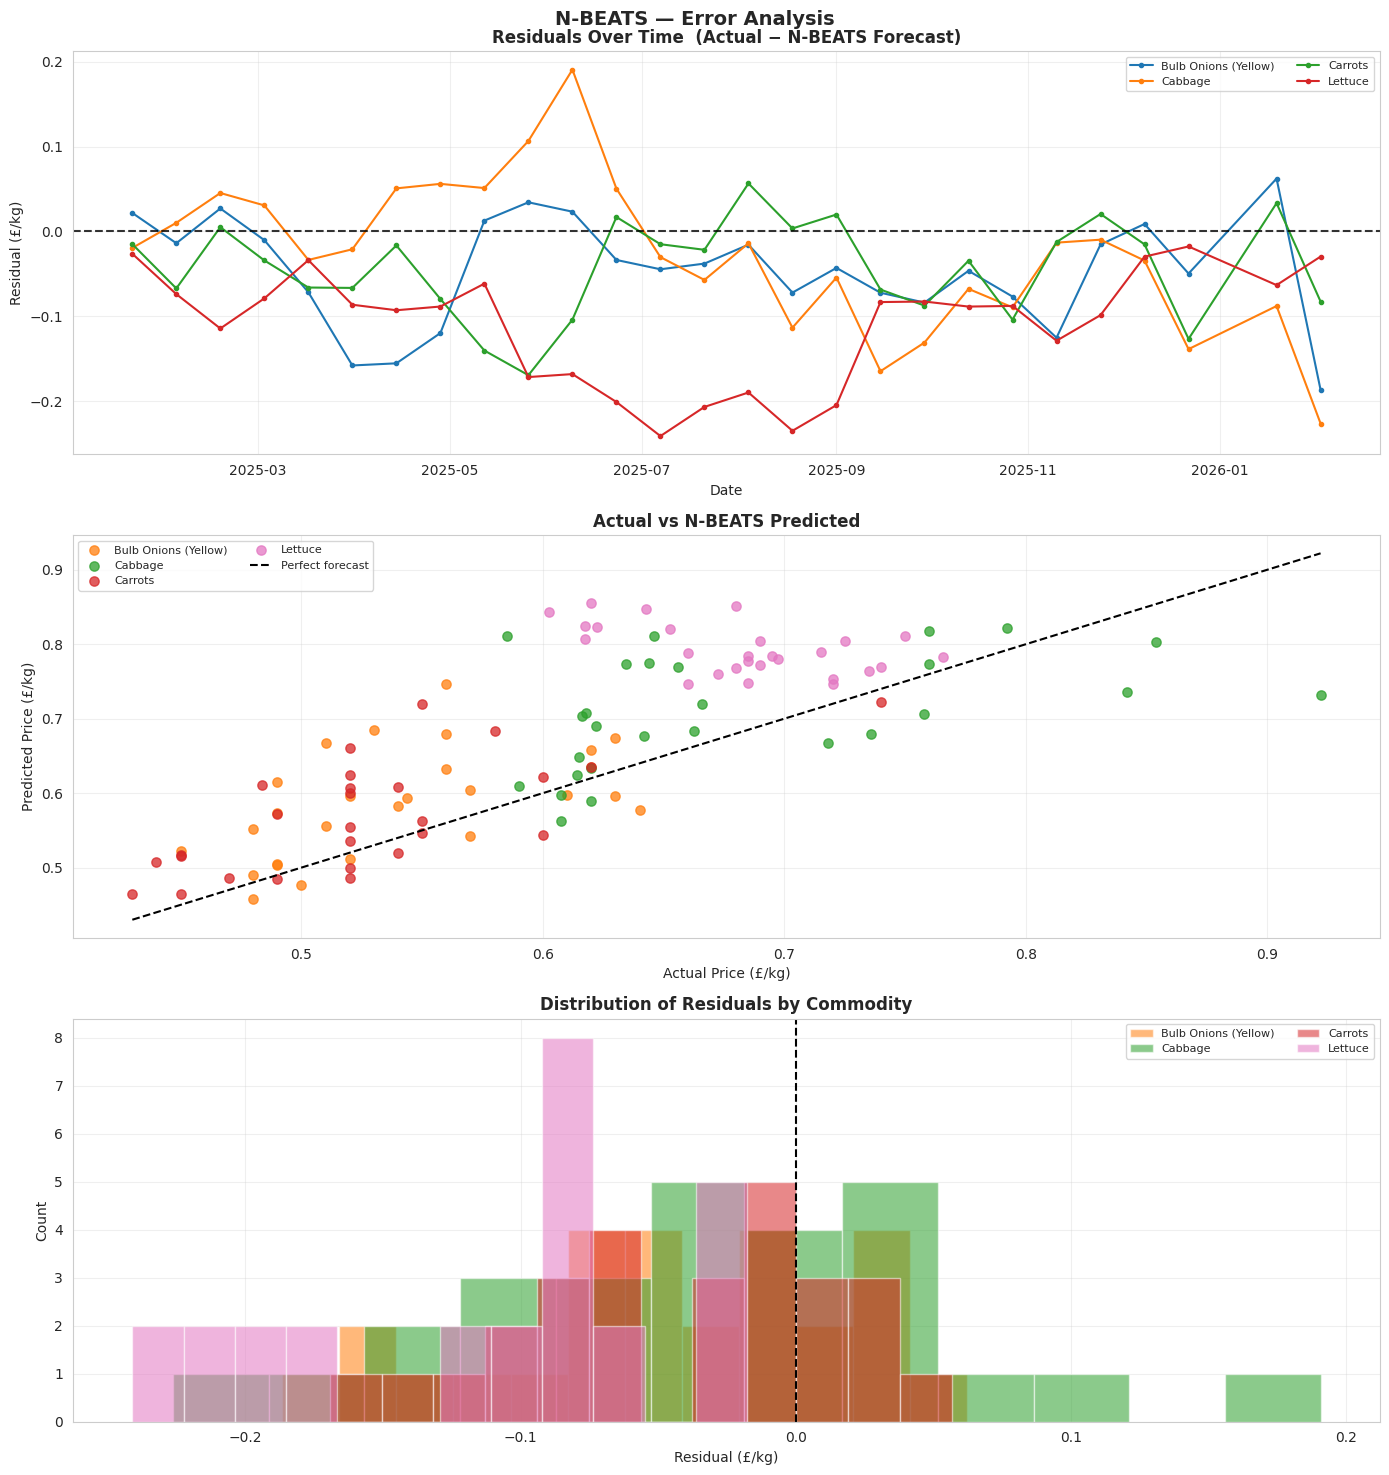

In [11]:
eval_real = eval_real.copy()
eval_real["residual"] = eval_real["y"] - eval_real["NBEATS"]

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# ── Panel 1: Residuals over time by commodity ──────────────────────────────
ax1 = axes[0]
for comm in commodities:
    sub = eval_real[eval_real["unique_id"] == comm].sort_values("ds")
    if len(sub) > 0:
        ax1.plot(sub["ds"], sub["residual"], label=comm, linewidth=1.5, marker="o", markersize=3)
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
ax1.set_title("Residuals Over Time  (Actual − N-BEATS Forecast)", fontweight="bold", fontsize=12)
ax1.set_xlabel("Date")
ax1.set_ylabel("Residual (£/kg)")
ax1.legend(fontsize=8, loc="upper right", ncol=2)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Actual vs Predicted scatter ──────────────────────────────────
ax2 = axes[1]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, comm in enumerate(commodities):
    sub = eval_real[eval_real["unique_id"] == comm]
    if len(sub) > 0:
        ax2.scatter(sub["y"], sub["NBEATS"], label=comm,
                    alpha=0.75, s=45, color=colors[i % len(colors)])
min_val = eval_real[["y", "NBEATS"]].min().min()
max_val = eval_real[["y", "NBEATS"]].max().max()
ax2.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1.5, label="Perfect forecast")
ax2.set_title("Actual vs N-BEATS Predicted", fontweight="bold", fontsize=12)
ax2.set_xlabel("Actual Price (£/kg)")
ax2.set_ylabel("Predicted Price (£/kg)")
ax2.legend(fontsize=8, loc="upper left", ncol=2)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Residual distribution per commodity ──────────────────────────
ax3 = axes[2]
for i, comm in enumerate(commodities):
    sub = eval_real[eval_real["unique_id"] == comm]
    if len(sub) > 0:
        ax3.hist(sub["residual"], bins=12, alpha=0.55, label=comm,
                 color=colors[i % len(colors)], edgecolor="white")
ax3.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax3.set_title("Distribution of Residuals by Commodity", fontweight="bold", fontsize=12)
ax3.set_xlabel("Residual (£/kg)")
ax3.set_ylabel("Count")
ax3.legend(fontsize=8, loc="upper right", ncol=2)
ax3.grid(True, alpha=0.3)

plt.suptitle("N-BEATS — Error Analysis", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

## 5 Forecast Plots

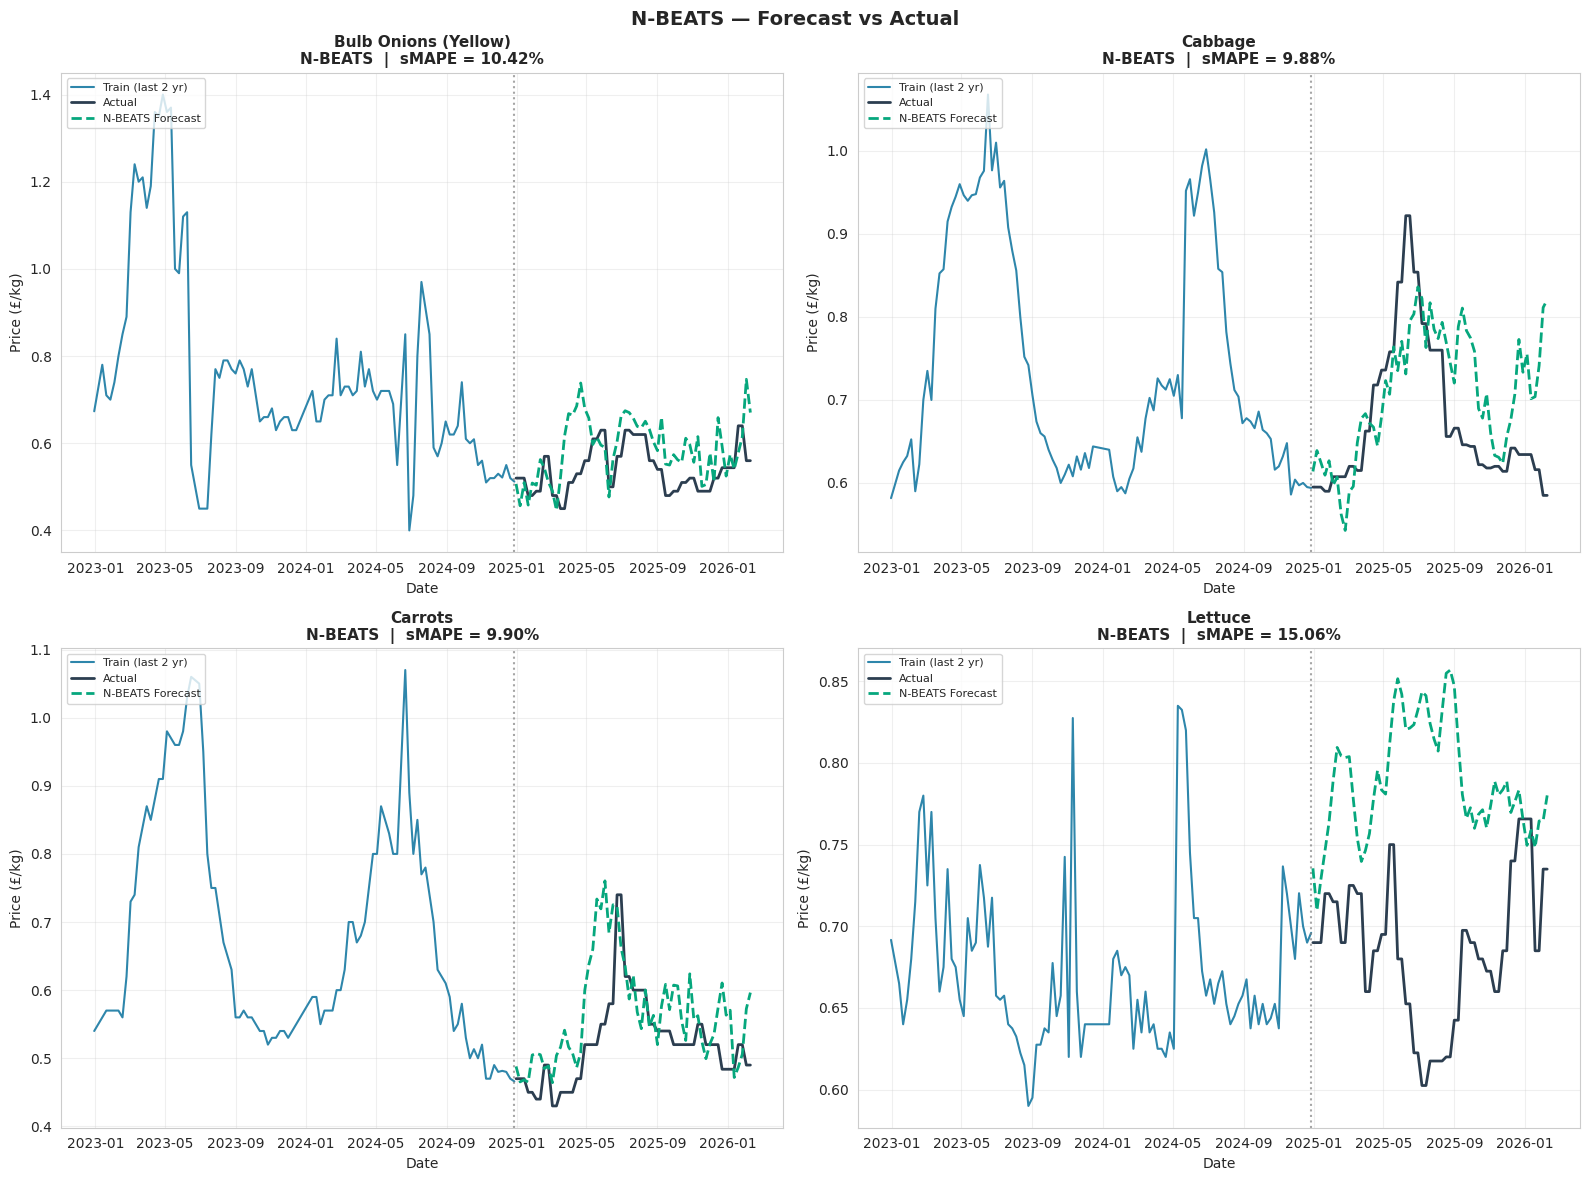

In [14]:
active_commodities = sorted(nf_train["unique_id"].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, comm in zip(axes, active_commodities):
    train_sub  = nf_train[nf_train["unique_id"] == comm].sort_values("ds")
    test_sub   = eval_df[eval_df["unique_id"] == comm].sort_values("ds")

    cutoff     = pd.Timestamp(train_sub["ds"].max()) - pd.DateOffset(years=2)
    train_tail = train_sub[train_sub["ds"] >= cutoff]
    train_end  = pd.Timestamp(train_sub["ds"].max())

    ax.plot(train_tail["ds"], train_tail["y"],
            label="Train (last 2 yr)", color="#2E86AB", linewidth=1.5)
    ax.plot(test_sub["ds"], test_sub["y"],
            label="Actual", color="#2c3e50", linewidth=2)
    ax.plot(test_sub["ds"], test_sub["NBEATS"],
            label="N-BEATS Forecast", color="#06A77D", linewidth=2, linestyle="--")
    ax.axvline(x=train_end, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)

    comm_row = per_commodity_df[per_commodity_df["Commodity"] == comm]
    if len(comm_row) > 0:
        smape_val = comm_row["sMAPE (%)"].values[0]
        ax.set_title(f"{comm}\nN-BEATS  |  sMAPE = {smape_val:.2f}%", fontweight="bold", fontsize=11)
    else:
        ax.set_title(comm, fontweight="bold", fontsize=11)

    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (£/kg)")

plt.suptitle("N-BEATS — Forecast vs Actual", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

## 6 Summary

In [13]:
print("\n=== N-BEATS Summary ===\n")
print(metrics_df.to_string(index=False))
print(f"\nForecast horizon         : {horizon} weeks")
print(f"Evaluation observations  : {len(eval_real)} (non-imputed only)")
print(f"Training time            : {train_elapsed:.1f}s")
print(f"Forecast time            : {forecast_elapsed:.1f}s")


=== N-BEATS Summary ===

   Metric     Value
      MSE  0.008923
     RMSE  0.094461
      MAE  0.073942
 MAPE (%) 12.297048
sMAPE (%) 11.314244

Forecast horizon         : 60 weeks
Evaluation observations  : 108 (non-imputed only)
Training time            : 14.3s
Forecast time            : 0.2s
